<a href="https://colab.research.google.com/github/ks-orintis/machine-learning/blob/main/%D0%9B%D0%A02_2_%D0%9B%D1%83%D1%87%D0%B0%D0%BD%D1%96%D0%BD%D0%BE%D0%B2%D0%B0_%D0%9A%D1%81%D0%B5%D0%BD%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Лабораторна робота 2.2**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1.


In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 21.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudshogaa/titanic-dataset/versions/1


In [4]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**PassengerId**: Унікальний ідентифікатор кожного пасажира.

**Survived**: Цей стовпець вказує, чи вижив пасажир (1), чи ні (0).

**Pclass** (Клас квитка): Показник соціально-економічного статусу: 1 — найвищий клас, 3 — найнижчий.

**Name**: Ім'я пасажира.

**Sex**: Стать пасажира.

**Age**: Вік пасажира. (Примітка: у цьому стовпці можуть бути відсутні значення.)

**SibSp**: Кількість братів, сестер або подружжя пасажира на борту «Титаніка».

**Parch**: Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket**: Номер квитка.

**Fare**: Вартість квитка, сплачена пасажиром.

2.
3.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

4.

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['Embarked'], axis=1, inplace=True)

5.

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


6.


In [11]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7.

In [12]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [13]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_521/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8.

In [14]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9.

In [15]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10.

In [16]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11.

In [17]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12.

In [18]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [19]:
print(f'Correlation between sex and servival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and servival: 0.5433513806577555


13.

In [20]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


14.

In [21]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


15.

In [28]:
fare_data = df[['Fare', 'Survived']].copy()

fare_data['Fare_Category'] = pd.qcut(
    fare_data['Fare'],
    6,
    labels=False
)

result = (
    fare_data.groupby('Fare_Category')['Survived']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

result.columns = ['Tariff group', 'Survival, %']

result

,Tariff group,"Survival, %"
0,0,20.51
1,1,19.08
2,2,36.69
3,3,43.62
4,4,41.78
5,5,69.80


Зі зростанням вартості квитка шанси пасажирів на виживання загалом підвищувались.

16.

In [23]:
result = (
    df.groupby('Pclass')['Fare']
    .mean()
    .round(2)
    .reset_index()
)

result.columns = ['Class', 'Average tariff']

result

,Class,Average tariff
0,1,84.15
1,2,20.66
2,3,13.68


Різниця у тарифах між класами значна: пасажири 1-го класу платили суттєво більше, ніж пасажири 2-го та 3-го класів.

17.

In [29]:
result = (
    df.groupby('Survived')['Age']
      .mean()
      .round(2)
      .reset_index()
)

result['Survived'] = result['Survived'].replace({
    0: 'Not survived',
    1: 'Survived'
})

result.columns = ['Status', 'Average age']

result

,Status,Average age
0,Not survived,30.03
1,Survived,28.29


Молодші пасажири мали дещо вищий рівень виживання, але різниця у середньому віці невелика.

18.

In [30]:
survival = (
    df.groupby(['Pclass', 'Sex'])['Survived']
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

survival.columns = ['Class', 'Sex', 'Survival, %']

survival

,Class,Sex,"Survival, %"
0,1,0,36.89
1,1,1,96.81
2,2,0,15.74
3,2,1,92.11
4,3,0,13.54
5,3,1,50.00


Жінки мали значно вищий рівень виживання в усіх класах. Найвищий рівень виживання спостерігався серед жінок 1-го класу.

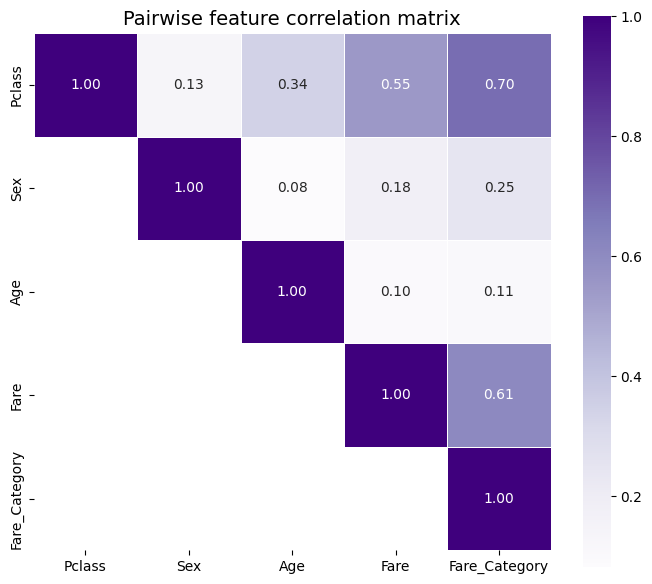

In [32]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    mtx,
    cmap='Purples',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool), k=-1),
    square=True,
    cbar=True,
    ax=ax
)

plt.title('Pairwise feature correlation matrix', fontsize=14)
plt.tight_layout()
plt.show()

**Частина 2**

Провести грунтовний аналіз даних.

In [33]:
import requests
from io import StringIO

url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C'

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df


,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регіон  28 non-null     object 
 1   1950    26 non-null     float64
 2   1960    27 non-null     float64
 3   1970    27 non-null     float64
 4   1990    28 non-null     float64
 5   2000    28 non-null     float64
 6   2012    28 non-null     float64
 7   2014    28 non-null     object 
 8   2019    28 non-null     object 
dtypes: float64(6), object(3)
memory usage: 2.1+ KB


In [35]:
print("Кількість рядків:", df.shape[0])
print("Кількість стовпців:", df.shape[1])

Кількість рядків: 28
Кількість стовпців: 9


In [36]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 0


In [46]:
df = df.replace(r'^\s*[—–−-]\s*$', np.nan, regex=True)

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [47]:
print("Загальна кількість пропусків:", df.isna().sum().sum())

Загальна кількість пропусків: 10


In [48]:
df = df.iloc[:-1].copy()

df.tail()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
22,Черкаська,20.5,17.9,14.4,12.3,7.5,10.0,9.8,6.4
23,Чернівецька,24.7,21.8,17.0,14.8,10.1,12.8,12.9,9.2
24,Чернігівська,22.0,18.3,12.7,10.8,6.9,9.4,9.0,6.1
25,Київ,NaN,17.4,15.9,12.0,7.3,12.0,12.1,11.0
26,Севастополь,NaN,NaN,NaN,12.5,7.0,12.0,NaN,NaN


In [49]:
year_columns = df.columns[1:]

df[year_columns] = df[year_columns].apply(pd.to_numeric, errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регіон  27 non-null     object 
 1   1950    25 non-null     float64
 2   1960    26 non-null     float64
 3   1970    26 non-null     float64
 4   1990    27 non-null     float64
 5   2000    27 non-null     float64
 6   2012    27 non-null     float64
 7   2014    25 non-null     float64
 8   2019    23 non-null     float64
dtypes: float64(8), object(1)
memory usage: 2.0+ KB


In [50]:
df[year_columns].describe()

,1950,1960,1970,1990,2000,2012,2014,2019
count,25.000000,26.000000,26.000000,27.000000,27.000000,27.000000,25.000000,23.000000
mean,23.104000,20.757692,15.600000,13.059259,8.222222,11.655556,11.144000,8.017391
std,2.879595,2.993750,1.905781,1.554462,1.584379,1.666718,2.053063,1.482827
min,18.600000,16.300000,12.700000,10.800000,6.100000,9.400000,5.100000,6.000000
25%,21.100000,18.525000,14.400000,12.150000,7.050000,10.300000,10.100000,6.800000
50%,22.400000,20.100000,15.300000,12.600000,7.900000,11.500000,11.200000,7.900000
75%,24.700000,22.175000,16.450000,14.100000,9.000000,12.300000,12.100000,8.800000
max,31.400000,27.300000,20.700000,16.800000,11.800000,15.900000,14.800000,11.000000


In [51]:
average_by_year = (
    df[year_columns]
    .mean()
    .round(2)
    .reset_index()
)

average_by_year.columns = ['Year', 'Average birth rate']

average_by_year

,Year,Average birth rate
0,1950,23.10
1,1960,20.76
2,1970,15.60
3,1990,13.06
4,2000,8.22
5,2012,11.66
6,2014,11.14
7,2019,8.02


In [52]:
df_filled = df.copy()

df_filled[year_columns] = df_filled[year_columns].fillna(df_filled[year_columns].mean())

df_filled

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.000,20.600000,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.400,19.200000,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.700,25.000000,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.400,20.400000,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.100,21.400000,14.0,10.9,6.1,9.8,8.200,8.017391
5,Житомирська,26.100,22.300000,15.9,12.9,8.9,12.2,12.000,7.900000
6,Закарпатська,31.400,27.300000,20.7,16.8,11.5,15.1,14.600,10.400000
7,Запорізька,21.900,19.700000,15.0,12.4,7.1,10.6,10.600,6.800000
8,Івано-Франківська,24.300,24.800000,18.2,15.5,10.3,12.4,12.200,8.800000
9,Київська,20.400,18.900000,15.6,12.3,7.3,12.2,12.100,8.000000


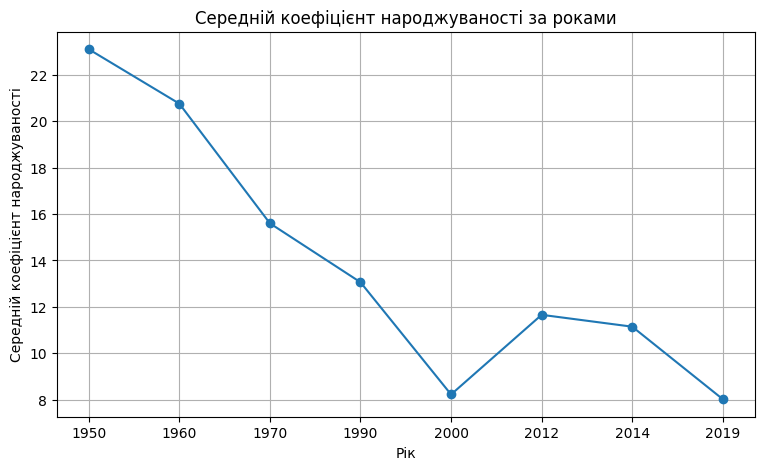

In [54]:
average_by_year = df[year_columns].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    year_columns.astype(str),
    average_by_year,
    marker='o'
)

plt.title('Середній коефіцієнт народжуваності за роками')
plt.xlabel('Рік')
plt.ylabel('Середній коефіцієнт народжуваності')
plt.grid(True)

plt.show()

 Загалом спостерігається значне зниження народжуваності: з понад 23 у 1950 році до близько 8 у 2019 році. Після мінімуму у 2000 році було тимчасове зростання у 2012-2014 роках.

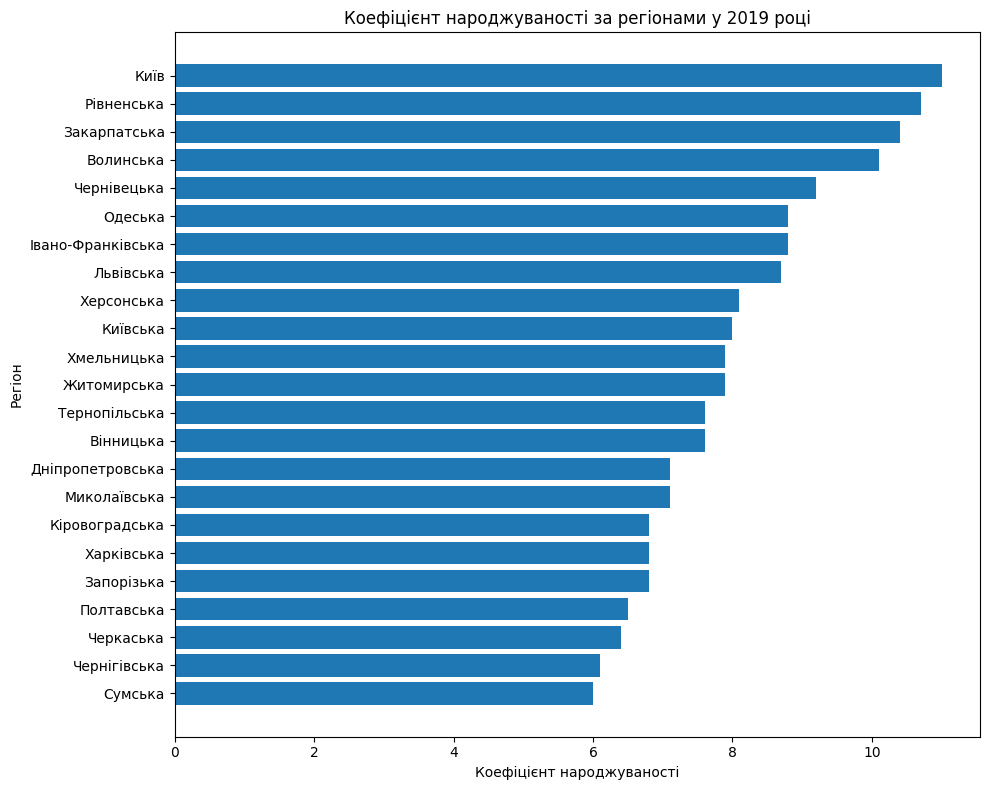

In [55]:
data_2019 = df[['Регіон', '2019']].dropna().sort_values('2019')

plt.figure(figsize=(10, 8))

plt.barh(
    data_2019['Регіон'],
    data_2019['2019']
)

plt.title('Коефіцієнт народжуваності за регіонами у 2019 році')
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('Регіон')

plt.tight_layout()
plt.show()

У 2019 році найвищий коефіцієнт народжуваності спостерігався у Києві, Рівненській та Закарпатській областях, а найнижчий - у Сумській та Чернігівській областях.

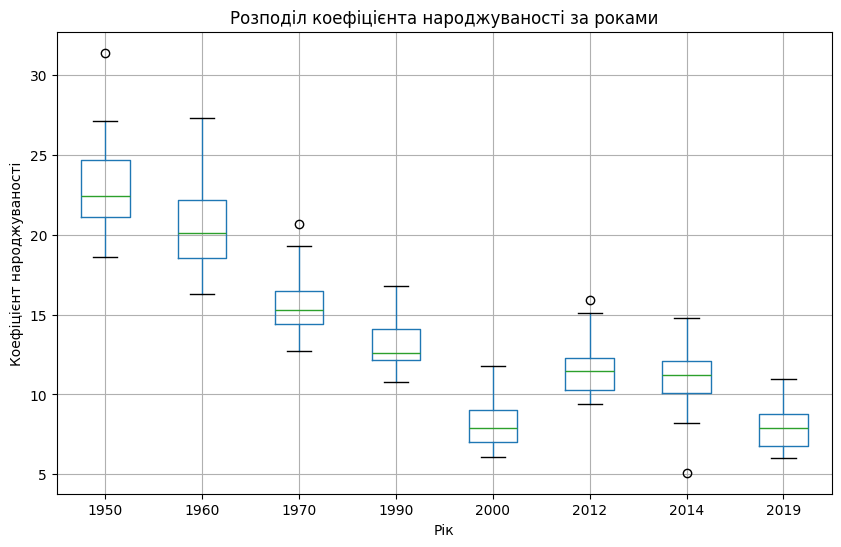

In [56]:
plt.figure(figsize=(10, 6))

df[year_columns].boxplot()

plt.title('Розподіл коефіцієнта народжуваності за роками')
plt.xlabel('Рік')
plt.ylabel('Коефіцієнт народжуваності')

plt.show()

Медіанний рівень народжуваності з роками зменшується. У ранні роки також спостерігається більший розкид значень між регіонами, ніж у пізніші періоди.

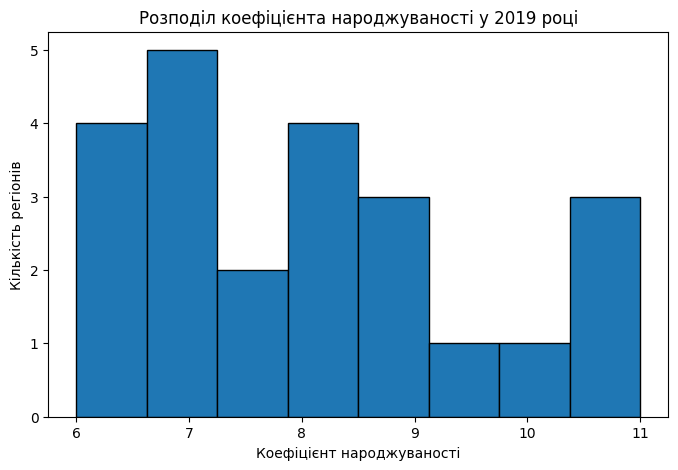

In [57]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['2019'].dropna(),
    bins=8,
    edgecolor='black'
)

plt.title('Розподіл коефіцієнта народжуваності у 2019 році')
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('Кількість регіонів')

plt.show()

У 2019 році більшість регіонів мали коефіцієнт народжуваності приблизно в межах 6-9, тоді як значення понад 9 траплялися рідше.